<a href="https://colab.research.google.com/github/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints/blob/main/pneumonia_baseline_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints.git

Cloning into 'Pneumonia-Detection-Under-Imaging-Constraints'...
remote: Enumerating objects: 5853, done.
remote: Total 5853 (delta 0), reused 0 (delta 0), pack-reused 5853 (from 1)
Receiving objects: 100% (5853/5853), 1.13 GiB | 31.24 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (5866/5866), done.


In [4]:
!ls Pneumonia-Detection-Under-Imaging-Constraints/data

test  train  val


/content/Pneumonia-Detection-Under-Imaging-Constraints
Folders in data: ['.DS_Store', 'train', 'test', 'val']
Train samples: 5216
Val samples: 16
Test samples: 624
Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([0, 1, 1, 1, 0, 1, 1, 0, 1, 1])


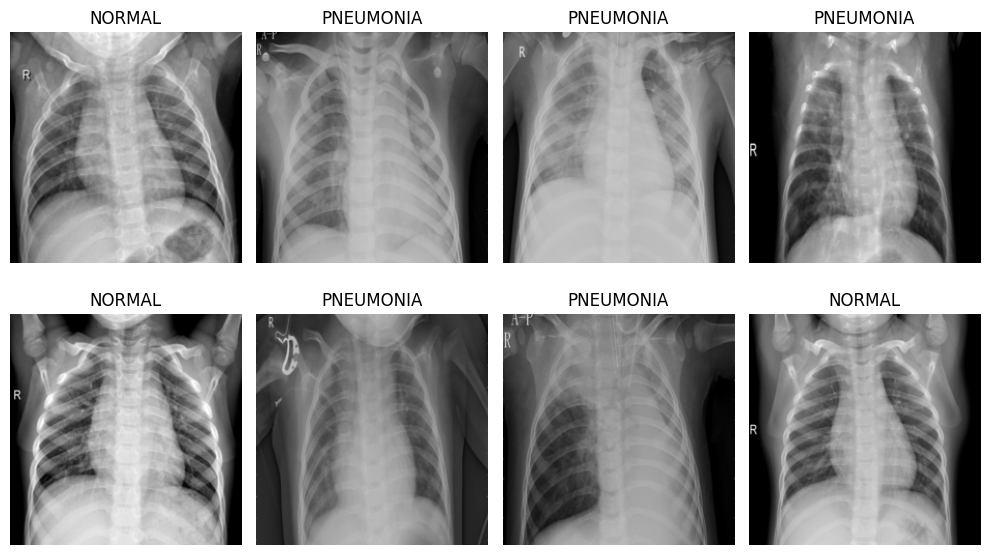

In [5]:
# =========================
# SETUP (run once)
# =========================

# move into repo
%cd Pneumonia-Detection-Under-Imaging-Constraints


# =========================
# IMPORTS
# =========================
import sys
import os
import torch
import matplotlib.pyplot as plt

# add src to path
sys.path.append(os.path.abspath("src"))

from dataset_generation import get_dataloaders


# =========================
# LOAD DATA
# =========================

# IMPORTANT: data path in Colab
base_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/data"

# quick check (optional but useful)
print("Folders in data:", os.listdir(base_path))

train_loader, val_loader, test_loader = get_dataloaders(base_path, batch_size=32)


# =========================
# DATASET SIZES
# =========================
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))


# =========================
# INSPECT ONE BATCH
# =========================
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels:", labels[:10])


# =========================
# VISUALIZATION
# =========================
def imshow(img):
    img = img.permute(1, 2, 0)  # CHW -> HWC
    img = img * 0.5 + 0.5       # unnormalize
    plt.imshow(img)
    plt.axis("off")


plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])

    label = "PNEUMONIA" if labels[i].item() == 1 else "NORMAL"
    plt.title(label)

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

def print_class_distribution(loader, name):
    labels = loader.dataset.labels  # from your custom dataset

    labels = np.array(labels)

    total = len(labels)
    num_normal = np.sum(labels == 0)
    num_pneumonia = np.sum(labels == 1)

    print(f"\n{name} SET")
    print(f"Total samples: {total}")
    print(f"NORMAL (0): {num_normal} ({num_normal/total:.2%})")
    print(f"PNEUMONIA (1): {num_pneumonia} ({num_pneumonia/total:.2%})")


# Run for each split
print_class_distribution(train_loader, "TRAIN")
print_class_distribution(val_loader, "VAL")
print_class_distribution(test_loader, "TEST")


TRAIN SET
Total samples: 5216
NORMAL (0): 1341 (25.71%)
PNEUMONIA (1): 3875 (74.29%)

VAL SET
Total samples: 16
NORMAL (0): 8 (50.00%)
PNEUMONIA (1): 8 (50.00%)

TEST SET
Total samples: 624
NORMAL (0): 234 (37.50%)
PNEUMONIA (1): 390 (62.50%)


/content/Pneumonia-Detection-Under-Imaging-Constraints
Using device: cuda
Data folders: ['.DS_Store', 'train', 'test', 'val']
Train samples: 5216
Val samples: 16
Test samples: 624
Class counts:
  NORMAL (0): 1341
  PNEUMONIA (1): 3875
Class weights: tensor([1.9448, 0.6730], device='cuda:0')
Epoch 01/8 | Train Loss: 0.2121 | Train Acc: 0.9076 | Test Loss: 0.8150 | Test Acc: 0.6955 | Val Loss: 1.2247 | Val Acc: 0.6250
Epoch 02/8 | Train Loss: 0.1032 | Train Acc: 0.9628 | Test Loss: 0.6255 | Test Acc: 0.7853 | Val Loss: 0.8266 | Val Acc: 0.6250
Epoch 03/8 | Train Loss: 0.0728 | Train Acc: 0.9734 | Test Loss: 0.3628 | Test Acc: 0.8782 | Val Loss: 0.4024 | Val Acc: 0.8125
Epoch 04/8 | Train Loss: 0.0573 | Train Acc: 0.9808 | Test Loss: 0.3912 | Test Acc: 0.8670 | Val Loss: 0.1828 | Val Acc: 1.0000
Epoch 05/8 | Train Loss: 0.0382 | Train Acc: 0.9872 | Test Loss: 0.9281 | Test Acc: 0.7837 | Val Loss: 0.3197 | Val Acc: 0.8750
Epoch 06/8 | Train Loss: 0.0332 | Train Acc: 0.9881 | Test Loss: 0.9

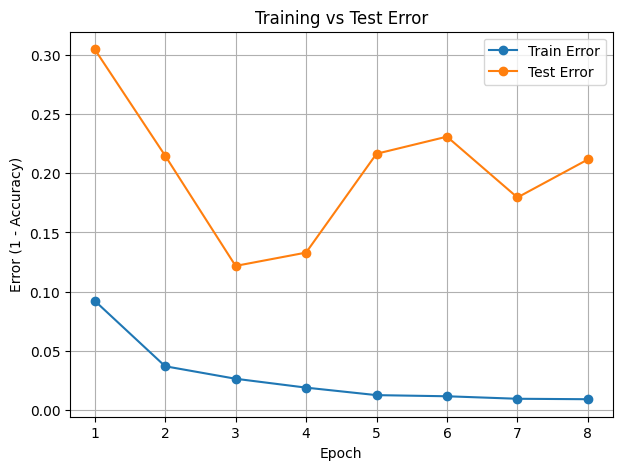

In [8]:
# =========================
# DenseNet training pipeline (Colab version, class-weighted loss)
# =========================

import sys
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torchvision.models import densenet121

# -------------------------
# Move into repo root
# -------------------------
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints

# allow notebook to access src/
sys.path.append(os.path.abspath("src"))
from dataset_generation import get_dataloaders


# -------------------------
# Config
# -------------------------
base_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/data"
batch_size = 32
num_epochs = 8
lr = 1e-4
weight_decay = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Data folders:", os.listdir(base_path))


# -------------------------
# Load data
# -------------------------
train_loader, val_loader, test_loader = get_dataloaders(base_path, batch_size=batch_size)

print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))


# -------------------------
# Compute class weights from training set
# -------------------------
train_labels = np.array(train_loader.dataset.labels)

num_normal = np.sum(train_labels == 0)
num_pneumonia = np.sum(train_labels == 1)
total = len(train_labels)

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

class_weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float32
).to(device)

print("Class counts:")
print(f"  NORMAL (0): {num_normal}")
print(f"  PNEUMONIA (1): {num_pneumonia}")
print("Class weights:", class_weights)


# -------------------------
# Build DenseNet-121
# -------------------------
model = densenet121(weights=None)

# replace classifier for binary classification
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)

model = model.to(device)


# -------------------------
# Loss / optimizer
# -------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


# -------------------------
# Evaluation function
# -------------------------
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }


# -------------------------
# Training loop
# -------------------------
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total_seen = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total_seen += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total_seen

    test_metrics = evaluate_model(model, test_loader, criterion, device)
    test_loss = test_metrics["loss"]
    test_acc = test_metrics["accuracy"]

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    val_metrics = evaluate_model(model, val_loader, criterion, device)
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.2f} minutes")


# -------------------------
# Load best model (by val loss)
# -------------------------
model.load_state_dict(best_model_wts)


# -------------------------
# Final validation metrics
# -------------------------
final_val_metrics = evaluate_model(model, val_loader, criterion, device)

print("\nFinal validation metrics (best model):")
print(f"Loss      : {final_val_metrics['loss']:.4f}")
print(f"Accuracy  : {final_val_metrics['accuracy']:.4f}")
print(f"Precision : {final_val_metrics['precision']:.4f}")
print(f"Recall    : {final_val_metrics['recall']:.4f}")
print(f"F1        : {final_val_metrics['f1']:.4f}")
print(f"AUC       : {final_val_metrics['auc']:.4f}")
print("Confusion matrix:")
print(final_val_metrics["confusion_matrix"])


# -------------------------
# Plot train vs test error
# -------------------------
train_error = [1 - acc for acc in history["train_acc"]]
test_error = [1 - acc for acc in history["test_acc"]]

plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), train_error, marker="o", label="Train Error")
plt.plot(range(1, num_epochs + 1), test_error, marker="o", label="Test Error")
plt.xlabel("Epoch")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Training vs Test Error")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(
    final_val_metrics["labels"],
    final_val_metrics["preds"]
)

print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.9375
